In [1]:
%tensorflow_version 2.x

TensorFlow 2.x selected.


In [2]:
from google.colab import drive
drive.mount('/gdrive')

Go to this URL in a browser: https://accounts.google.com/o/oauth2/auth?client_id=947318989803-6bn6qk8qdgf4n4g3pfee6491hc0brc4i.apps.googleusercontent.com&redirect_uri=urn%3aietf%3awg%3aoauth%3a2.0%3aoob&response_type=code&scope=email%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdocs.test%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive.photos.readonly%20https%3a%2f%2fwww.googleapis.com%2fauth%2fpeopleapi.readonly

Enter your authorization code:
··········
Mounted at /gdrive


In [3]:
import os
import tensorflow as tf
import numpy as np
import pandas as pd
import gensim
import en_core_web_sm
from tensorflow.python.keras import Model, layers as lrs
from dataclasses import dataclass, field
from sklearn.model_selection import GridSearchCV, StratifiedKFold

print(tf.__version__)

2.1.0-rc1


In [4]:
resolver = tf.distribute.cluster_resolver.TPUClusterResolver(tpu='grpc://' + os.environ['COLAB_TPU_ADDR'])
tf.config.experimental_connect_to_cluster(resolver)
tf.tpu.experimental.initialize_tpu_system(resolver)
strategy = tf.distribute.experimental.TPUStrategy(resolver)

INFO:tensorflow:Initializing the TPU system: 10.44.33.242:8470


INFO:tensorflow:Initializing the TPU system: 10.44.33.242:8470


INFO:tensorflow:Clearing out eager caches


INFO:tensorflow:Clearing out eager caches


INFO:tensorflow:Finished initializing TPU system.


...

INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:worker/replica:0/task:0/device:TPU:7, TPU, 0, 0)


INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:worker/replica:0/task:0/device:TPU_SYSTEM:0, TPU_SYSTEM, 0, 0)


INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:worker/replica:0/task:0/device:TPU_SYSTEM:0, TPU_SYSTEM, 0, 0)


INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:worker/replica:0/task:0/device:XLA_CPU:0, XLA_CPU, 0, 0)


INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:worker/replica:0/task:0/device:XLA_CPU:0, XLA_CPU, 0, 0)


In [5]:
%cd /gdrive/My\ Drive/UJ/Stopień\ II/Semestr\ III/data_science/project

!ls -lhR

/gdrive/My Drive/UJ/Stopień II/Semestr III/data_science/project
.:
total 4.0K
drwx------ 2 root root 4.0K Jan 22 07:23 dataset

./dataset:
total 255M
-rw------- 1 root root 6.0M Jan 22 07:23 sample_submission.csv
-rw------- 1 root root  58M Jan 22 07:23 test.csv
-rw------- 1 root root 4.8M Jan 22 07:23 test_labels.csv
-rw------- 1 root root  55M Jan 22 07:23 test_preprocessed.csv
-rw------- 1 root root  66M Jan 22 07:23 train.csv
-rw------- 1 root root  66M Jan 22 07:23 train_preprocessed.csv


## Download data

In [6]:
nlp = en_core_web_sm.load()
nlp

In [0]:
dataset_path = 'dataset'
df = pd.read_csv('dataset/train.csv')

In [8]:
train_set = (df.assign(toxic=df[['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']]
             .values.max(axis=1))
             .drop(columns=['id', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']))
train_set

,comment_text,toxic
0,Explanation\nWhy the edits made under my usern...,0
1,D'aww! He matches this background colour I'm s...,0
2,"Hey man, I'm really not trying to edit war. It...",0
3,"""\nMore\nI can't make any real suggestions on ...",0
4,"You, sir, are my hero. Any chance you remember...",0
...,...,...
159566,""":::::And for the second time of asking, when ...",0
159567,You should be ashamed of yourself \n\nThat is ...,0
159568,"Spitzer \n\nUmm, theres no actual article for ...",0
159569,And it looks like it was actually you who put ...,0


In [0]:
targets = train_set['toxic']

In [10]:
train_set[train_set['toxic'] > 0]

,comment_text,toxic
6,COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK,1
12,Hey... what is it..\n@ | talk .\nWhat is it......,1
16,"Bye! \n\nDon't look, come or think of comming ...",1
42,You are gay or antisemmitian? \n\nArchangel WH...,1
43,"FUCK YOUR FILTHY MOTHER IN THE ASS, DRY!",1
...,...,...
159494,"""\n\n our previous conversation \n\nyou fuckin...",1
159514,YOU ARE A MISCHIEVIOUS PUBIC HAIR,1
159541,Your absurd edits \n\nYour absurd edits on gre...,1
159546,"""\n\nHey listen don't you ever!!!! Delete my e...",1


## Preprocess

In [11]:
words = pd.DataFrame(list(train_set['comment_text']
                   .str.lower()
                   .apply(gensim.parsing.preprocessing.strip_punctuation)
                   .apply(gensim.parsing.preprocessing.strip_non_alphanum)
                   .apply(gensim.parsing.preprocessing.strip_numeric)
                   .apply(gensim.parsing.preprocessing.strip_multiple_whitespaces)
                   .str.strip()
                   .apply(gensim.utils.tokenize)
                )).iloc[:, :300]

words

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,...,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299
0,explanation,why,the,edits,made,under,my,username,hardcore,metallica,fan,were,reverted,they,weren,t,vandalisms,just,closure,on,some,gas,after,i,voted,at,new,york,dolls,fac,and,please,don,t,remove,the,template,from,the,talk,...,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
1,d,aww,he,matches,this,background,colour,i,m,seemingly,stuck,with,thanks,talk,january,utc,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
2,hey,man,i,m,really,not,trying,to,edit,war,it,s,just,that,this,guy,is,constantly,removing,relevant,information,and,talking,to,me,through,edits,instead,of,my,talk,page,he,seems,to,care,more,about,the,formatting,...,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
3,more,i,can,t,make,any,real,suggestions,on,improvement,i,wondered,if,the,section,statistics,should,be,later,on,or,a,subsection,of,types,of,accidents,i,think,the,references,may,need,tidying,so,that,they,are,all,in,...,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
4,you,sir,are,my,hero,any,chance,you,remember,what,page,that,s,on,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159566,and,for,the,second,time,of,asking,when,your,view,completely,contradicts,the,coverage,in,reliable,sources,why,should,anyone,care,what,you,feel,you,can,t,even,give,a,consistent,argument,is,the,opening,only,supposed,to,mention,significant,...,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
159567,you,should,be,ashamed,of,yourself,that,is,a,horrible,thing,you,put,on,my,talk,page,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
159568,spitzer,umm,theres,no,actual,article,for,prostitution,ring,crunch,captain,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
159569,and,it,looks,like,it,was,act

In [0]:
del train_set

In [13]:
unique_words = pd.Index(words.stack().append(pd.Series(['<pad>', '<unk>'])).drop_duplicates().reset_index(drop=True))
unique_words

Index(['explanation', 'why', 'the', 'edits', 'made', 'under', 'my', 'username',
       'hardcore', 'metallica',
       ...
       'psilocybin', 'bmattson', 'webaddress', 'gratest', 'kakatiyas',
       'hanumakonda', 'automakers', 'ciu', '<pad>', '<unk>'],
      dtype='object', length=164212)

In [14]:
index_of_padding = unique_words.get_loc('<pad>')
index_of_padding

164210

In [15]:
index_of_unknown = unique_words.get_loc('<unk>')
index_of_unknown

164211

In [0]:
def word2vec(word):
    return unique_words.get_loc(word) if word in unique_words else index_of_unknown

In [17]:
words[words.isna()] = index_of_padding
words

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,...,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299
0,explanation,why,the,edits,made,under,my,username,hardcore,metallica,fan,were,reverted,they,weren,t,vandalisms,just,closure,on,some,gas,after,i,voted,at,new,york,dolls,fac,and,please,don,t,remove,the,template,from,the,talk,...,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210
1,d,aww,he,matches,this,background,colour,i,m,seemingly,stuck,with,thanks,talk,january,utc,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,...,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210
2,hey,man,i,m,really,not,trying,to,edit,war,it,s,just,that,this,guy,is,constantly,removing,relevant,information,and,talking,to,me,through,edits,instead,of,my,talk,page,he,seems,to,care,more,about,the,formatting,...,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210
3,more,i,can,t,make,any,real,suggestions,on,improvement,i,wondered,if,the,section,statistics,should,be,later,on,or,a,subsection,of,types,of,accidents,i,think,the,references,may,need,tidying,so,that,they,are,all,in,...,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210
4,you,sir,are,my,hero,any,chance,you,remember,what,page,that,s,on,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,...,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159566,and,for,the,second,time,of,asking,when,your,view,completely,contradicts,the,coverage,in,reliable,sources,why,should,anyone,care,what,you,feel,you,can,t,even,give,a,consistent,argument,is,the,opening,only,supposed,to,mention,significant,...,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210
159567,you,should,be,ashamed,of,yourself,that,is,a,horrible,thing,you,put,on,my,talk,page,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,164210,...,164210,164210,164210,164210,164210,1642

In [18]:
vectors = words.applymap(word2vec)
vectors

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,...,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299
0,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,15,33,2,34,35,2,36,...,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211
1,42,43,44,45,46,47,48,23,39,49,50,51,52,36,53,54,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,...,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211
2,55,56,23,39,57,58,59,60,61,62,63,64,17,65,46,66,67,68,69,70,71,30,72,60,73,74,3,75,76,6,36,37,44,77,60,78,79,80,2,81,...,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211
3,79,23,85,15,86,87,88,89,19,90,23,91,92,2,93,94,95,96,97,19,98,99,100,76,101,76,102,23,103,2,104,105,106,107,108,65,13,109,110,111,...,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211
4,124,152,109,6,153,87,154,124,155,156,37,65,64,19,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,...,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159566,30,127,2,1339,725,76,3022,254,167,573,1623,26676,2,6725,111,1284,653,1,95,575,78,156,124,940,124,85,15,475,1576,99,233,341,67,2,5609,357,2626,60,1625,2325,...,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211
159567,124,95,96,8437,76,130,65,67,99,2943,704,124,1152,19,6,36,37,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,...,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211
159568,78467,10774,2476,119,83,149,127,7584,2100,23751,3881,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,164211,

In [19]:
nlp.max_length = 2000000

with strategy.scope():
    embeddings = pd.DataFrame(word.vector for word in nlp(' '.join(unique_words)))

embeddings

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,...,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95
0,9.220971,-2.461792,1.990567,1.179825,-1.491817,0.284530,-0.123853,3.073905,-6.917295,1.303448,1.266999,-0.936129,-1.707296,-2.115730,3.763748,-0.651663,1.533256,1.009768,0.419553,5.700890,-0.884866,-1.677222,0.529619,2.461537,-0.846211,-3.299846,-3.225139,-2.621646,0.015812,5.180274,6.182981,0.217043,0.546181,-1.304977,-3.318721,2.295052,1.092822,0.893683,-1.754950,6.289861,...,1.461834,-0.977261,-2.625523,-1.962451,-1.873611,2.227271,5.274659,-0.374261,-1.608445,0.644350,-0.824308,1.796421,-1.138423,6.846262,3.154534,-2.712365,-0.065700,1.555194,0.715379,1.229845,-0.375765,1.764349,-3.220489,-1.087677,1.064155,-1.058251,-0.799888,0.789361,-4.663664,1.979514,-0.768223,-1.073944,6.587417,-1.097343,-0.751205,0.925571,-0.414497,-3.278460,-1.277933,6.828188
1,-1.608694,1.219239,0.875067,-6.171174,-1.365010,-3.387005,-4.457975,0.392606,-0.396887,4.351595,-3.032815,-2.845447,-0.312032,1.819258,1.917670,0.236712,-0.362237,3.717967,0.168520,2.858549,0.175752,-1.769627,0.274701,0.747289,-0.290767,-1.035672,-4.740161,7.146540,-1.290134,0.756406,3.200413,1.840400,-0.719978,1.681033,-0.733860,4.217897,0.884341,-4.603222,1.771150,-2.690336,...,-2.922832,-1.462501,1.168394,-2.100269,3.202742,-1.273679,-4.158380,-3.011158,-1.471803,0.459875,2.232212,2.533406,5.542763,1.487959,0.500193,-2.361545,-1.499833,5.634171,-3.122350,-7.014150,-1.764171,-3.039361,4.379284,-1.309869,3.945784,1.433161,-0.874946,1.005149,-1.909920,-0.104691,2.658044,1.906338,1.163329,1.859341,-0.911358,1.021724,-1.700674,1.339092,-0.149646,6.783923
2,-4.014997,-3.068882,-2.383906,0.133554,0.631333,-0.099784,-0.034641,-3.515921,-0.679200,-1.440483,3.383353,2.944583,-2.590764,-2.205251,-1.263772,-1.575134,-1.100181,3.387122,5.109291,0.921652,3.173349,-1.009604,2.696266,0.931826,-0.713269,0.109325,2.974334,-0.292014,-2.042007,1.787648,1.284434,-2.584493,-3.544832,-2.054996,1.967936,-2.085365,3.488928,6.655001,-1.043933,-1.091177,...,-3.305730,0.345429,-1.264875,1.740291,-3.523729,-5.018185,0.191366,2.749398,-0.706065,-2.750269,5.122256,-3.230392,-3.152581,-3.182426,0.184251,-2.293066,3.433965,-2.740827,1.563488,-0.522617,2.317640,-0.679212,-2.732512,-3.098027,-3.079440,3.369051,1.651678,-0.869327,1.250145,3.683692,4.887650,-0.130176,-0.657977,3.352048,1.691032,2.409577,-1.905607,4.977948,0.809970,-1.739498
3,2.547375,2.274726,3.966151,-2.488713,0.312271,2.990818,5.188634,-0.132417,0.791126,2.578127,-5.765917,2.999483,-3.987350,1.394550,-0.005091,-2.508363,1.583760,0.049273,5.719970,1.424700,0.498897,3.606229,0.225228,-1.472459,-0.017738,-0.435943,2.860750,-2.739706,-2.820046,-1.589442,3.632183,-0.339253,-2.297636,0.372558,-0.360454,3.302598,-5.264328,7.260966,-0.878203,1.576450,...,-1.066904,2.080573,1.008473,0.209099,-1.901640,0.437048,1.437949,-0.408829,2.521797,7.306173,-1.594201,0.487019,-1.952911,-1.980836,-3.305933,-0.921320,1.109927,0.432772,0.180424,-0.376165,1.452455,-3.665092,-1.392553,-0.346920,-1.161288,-4.010107,-1.554844,-1.933325,1.351216,-1.046937,-3.054312,-0.086697,-0.864940,0.302875,-1.501583,-1.859840,-1.856027,1.716825,-1.943816,-2.772171
4,-2.969959,1.893171,-2.365045,-1.618393,3.926053,2.919884,1.179293,-1.310701,4.741217,-2.853442,2.362748,-0.996981,-0.016399,-1.305679,-2.133649,5.412302,0.223508,0.778106,-2.923901,-1.993722,2.943578,-0.071960,1.702659,-1.999582,1.754015,-0.562830,-0.007930,-2.917980,0.127689,2.156557,1.650808,3.891321,-0.843799,8.111043,3.433446,0.476101,-3.161224,0.208932,-2.156998,2.000596,...,-1.020205,-3.310864,-3.792070,1.178657,1.455172,1.030830,-2.686364,-2.638084,1.274103,-0.910695,4.919188,1.631427,-4.285472,2.820539,-0.767662,-3.381860,-1.077095,-0.572546,-0.141106,-0.437528,-0.092250,-3.956331,0.653426,2.693653,4.962122,-5.457764,-2.612547,-3.727358,-1.198869,-3.972537,2.467419,2.081398,0.3

In [0]:
class Layer(tf.keras.layers.Layer):
    def __init__(self):
        super().__init__()
        self.l1 = lrs.GlobalAveragePooling1D()
        self.l2 = lrs.GlobalMaxPooling1D()

    def call(self, x):
        avg_pool = self.l1(x)
        max_pool = self.l2(x)
        return lrs.concatenate([avg_pool, max_pool])


In [0]:
def build_model(learning_rate):
    model = tf.keras.Sequential((
        lrs.Embedding(embeddings.shape[0], embeddings.shape[1], weights=[embeddings], trainable=False),
        lrs.SpatialDropout1D(0.35),
        lrs.Bidirectional(lrs.LSTM(128, return_sequences=True)),
        lrs.Conv1D(64, kernel_size=3, padding='valid'),
        Layer(),
        lrs.Dense(1, activation='sigmoid')
    ))

    model.compile(
        loss='binary_crossentropy',
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        metrics=['accuracy', tf.metrics.AUC()]
    )
    return model

In [0]:
param_grid = {
    'batch_size': [32, 64, 128],
    'learning_rate': [0.001, 0.01]
}

In [23]:
with strategy.scope():
    k_model = tf.keras.wrappers.scikit_learn.KerasClassifier(build_fn=build_model, verbose=0)
    clf = GridSearchCV(estimator=k_model, param_grid=param_grid, cv=StratifiedKFold(n_splits=2, shuffle=True, random_state=1234),
                    scoring='accuracy', verbose=100, n_jobs=1)
clf

GridSearchCV(cv=StratifiedKFold(n_splits=2, random_state=1234, shuffle=True),
             error_score=nan,
             estimator=<tensorflow.python.keras.wrappers.scikit_learn.KerasClassifier object at 0x7f58cff5b240>,
             iid='deprecated', n_jobs=1,
             param_grid={'batch_size': [32, 64, 128],
                         'learning_rate': [0.001, 0.01]},
             pre_dispatch='2*n_jobs', refit=True, return_train_score=False,
             scoring='accuracy', verbose=100)

In [24]:
with strategy.scope():
    clf.fit(
        vectors[:- (len(vectors) % 128)],
        targets[:- (len(vectors) % 128)]
    )

Fitting 2 folds for each of 6 candidates, totalling 12 fits
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[CV] batch_size=32, learning_rate=0.001 ..............................
[CV] .. batch_size=32, learning_rate=0.001, score=0.944, total= 2.5min
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  2.5min remaining:    0.0s
[CV] batch_size=32, learning_rate=0.001 ..............................
[CV] .. batch_size=32, learning_rate=0.001, score=0.945, total= 2.5min
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:  5.0min remaining:    0.0s
[CV] batch_size=32, learning_rate=0.01 ...............................
[CV] ... batch_size=32, learning_rate=0.01, score=0.934, total= 2.5min
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:  7.5min remaining:    0.0s
[CV] batch_size=32, learning_rate=0.01 ...............................
[CV] ... batch_size=32, learning_rate=0.01, score=0.932, total= 2.5min
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed

In [25]:
clf.best_score_

0.9446604133226324

In [26]:
clf.best_params_

{'batch_size': 32, 'learning_rate': 0.001}

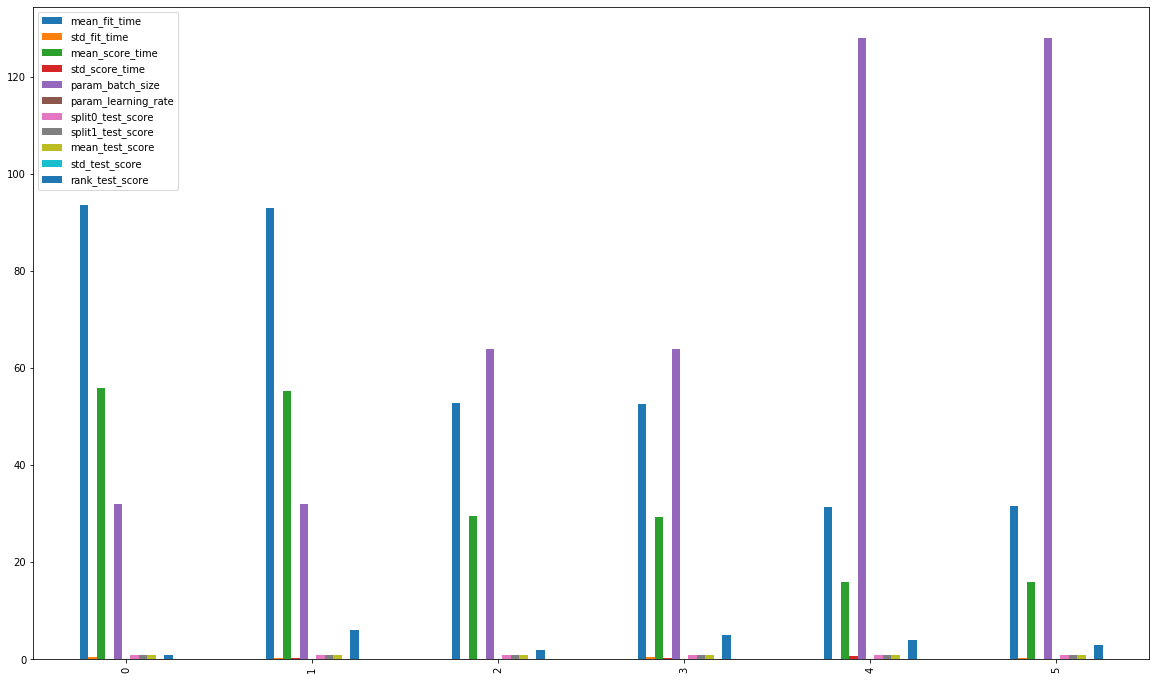

In [51]:
pd.DataFrame(clf.cv_results_).plot.bar(figsize=(20, 12));

In [0]:
best_model = clf.best_estimator_

In [58]:
with strategy.scope():
    history = best_model.fit(
        vectors[:- (len(vectors) % 128)],
        targets[:- (len(vectors) % 128)],
        epochs=5,
        verbose=10
    )

Train on 159488 samples
Epoch 1/5
Epoch 2/5
Epoch 3/5
Epoch 4/5
Epoch 5/5


In [76]:
pd.DataFrame(history.params)

,batch_size,epochs,steps,samples,verbose,do_validation,metrics
0,32,5,4984,159488,10,False,loss
1,32,5,4984,159488,10,False,accuracy
2,32,5,4984,159488,10,False,auc_15


In [66]:
history_df = pd.DataFrame(history.history)
history_df

,loss,accuracy,auc_15
0,0.197213,0.933512,0.887870
1,0.155029,0.947720,0.932441
2,0.145395,0.950680,0.940990
3,0.140265,0.951695,0.946657
4,0.134704,0.953671,0.950780


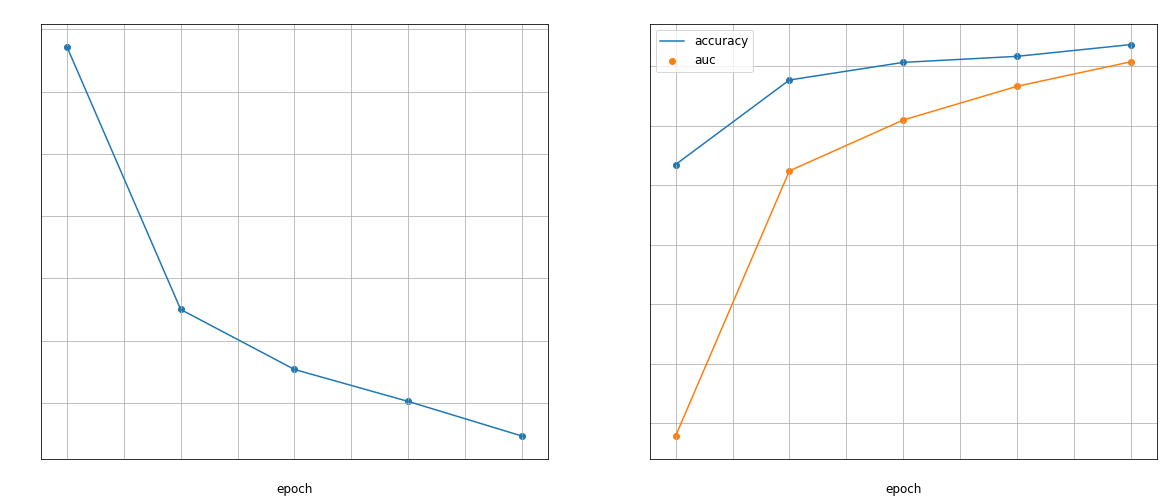

In [74]:
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 12, 'xtick.color': 'white', 'ytick.color': 'white'})

fig = plt.figure(figsize=[20, 8])
ax1, ax2 = fig.subplots(1, 2, sharex=True)

ax1.set_title('loss', color='white')
ax1.set_xlabel('epoch')
ax1.grid()

ax1.plot(history_df['loss'])
ax1.scatter(range(5), history_df['loss'])


ax2.set_title('metrics', color='white')
ax2.set_xlabel('epoch')
# ax2.set_ylim(50, 100)
ax2.grid()

ax2.plot(history_df['accuracy'] * 100., label=f'accuracy')
ax2.scatter(range(5), history_df['accuracy'] * 100.)
ax2.plot(history_df['auc_15'] * 100.)
ax2.scatter(range(5), history_df['auc_15'] * 100., label=f'auc')

ax2.legend()

plt.show();

In [77]:
history_df['accuracy'].max()

0.9536705017089844

In [78]:
history_df['auc_15'].max()

0.950779914855957